# Computer Vision

Computer Vision (CV) is a broad subfield of Artificial Intelligence focused on extracting structured, meaningful information from digital images and videos.

At the hardware level, images are stored as multi-dimensional numerical grids (tensors) of dimension $H \times W \times C$ (Height $\times$ Width $\times$ Channels). While everyday images contain 3 channels—Red, Green, Blue (RGB)—domain applications like remote sensing, bio-imaging, or medical diagnostics frequently extend into multi-spectral, hyperspectral, or 3D volumetric data.

To turn these raw numerical grids into scientific insights, computer vision relies on a hierarchy of core tasks.

Computer vision tasks range from simple whole-image labeling to dense, pixel-by-pixel spatial analysis.

### Image Classification

* **What it does:** Assigns a single categorical label to an entire image.
* **Output:** A class name and confidence score (e.g., `["Diseased Leaf", 0.94]`).
* **Spatial Info:** Zero. It tells you *what* is in the image, but not *where* it is located.

### Object Detection

* **What it does:** Draws 2D rectangular bounding boxes around individual items of interest and assigns each a class label and confidence score.
* **Output:** Coordinates $(x, y, w, h)$ + class label + confidence score.
* **Context:** Crowd-sourcing platforms (like CAPTCHA challenges) often collect annotated data for training these models.
* **Class Types:** Traditional models are *closed-vocabulary* (limited to pre-trained classes), whereas modern models support *open-vocabulary* detection via natural language prompts.

### Semantic Segmentation

* **What it does:** Groups every pixel into a categorical class (e.g., "person," "vegetation," "water").
* **Output:** A color-coded pixel mask representing semantic regions.
* **Key Limitation:** It does not distinguish between separate instances of the same class. If three overlapping cells are detected, semantic segmentation colors them as one contiguous region.

### Instance Segmentation

* **What it does:** Focuses strictly on countable, distinct objects (referred to as **"things"**). It detects each individual item and outputs a precise, pixel-level outline.
* **Output:** Distinct mask boundaries for `Object 1`, `Object 2`, and `Object 3`.
* **Key Limitation:** It completely ignores amorphous background regions (referred to as **"stuff"**), leaving pixels like bare ground, sky, or ocean unclassified.

### Panoptic Segmentation

* **What it does:** Unifies semantic and instance segmentation to deliver total scene understanding. Every single pixel in the image is classified.
* **Data Categorization:**
* **"Things":** Countable, distinct objects with defined geometry (e.g., animals, vehicles, individual trees, cellular structures). These receive unique instance IDs.
* **"Stuff":** Continuous, amorphous background regions or textures (e.g., soil, sky, bodies of water, canopy cover). These receive semantic labels, but no instance IDs.



### Summary examples

| Task | Output Type | Spatial Precision | Primary Domain Use Case |
| --- | --- | --- | --- |
| **Classification** | Global Label | None | Rapid screening (e.g., tumor vs. benign tissue) |
| **Object Detection** | Bounding Box $(x, y, w, h)$ | Coarse (Rectangular) | Inventory counting, species detection in camera traps |
| **Semantic Segmentation** | Category per Pixel | Fine (Area-based) | Land-cover mapping, ocean chlorophyll density |
| **Instance Segmentation** | Individual Masks | Fine (Object-based) | Tracking individual cell counts, particle sizing |
| **Panoptic Segmentation** | Complete Pixel Map | Fine (Total Scene) | Autonomous field robotics, complete ecosystem mapping |


### Convolutional Neural Networks (CNNs)

CNNs were the foundational architecture for computer vision. They rely on the principle of **spatial locality**—the assumption that a pixel is most strongly related to its immediate neighbors.

1. **Sliding Windows (Convolutions):** A small matrix filter (e.g., $3 \times 3$ pixels) slides across the image grid, performing mathematical dot products at each position to detect features.
2. **Feature Hierarchies:** Early layers detect low-level geometric primitives (edges, gradients, color transitions). Deeper layers combine these primitives into complex semantic structures (textures, organ boundaries, species-specific patterns).
3. **Translation Invariance:** A CNN recognises an object regardless of where it appears in the frame.

### Vision Transformers (ViTs)

Transformers—originally developed for Natural Language Processing (NLP)—redefined vision research by removing the constraint of spatial locality.

1. **Image Patching:** Instead of sliding a tiny window, a ViT splits an image into a grid of non-overlapping patches (e.g., $16 \times 16$ pixels) and flattens them into a sequence of "tokens," treating them like words in a sentence.
2. **Self-Attention Mechanism:** ViTs calculate dynamic mathematical relationships (attention weights) between every patch and every other patch simultaneously.
3. **Global Receptive Field:** Unlike CNNs, which build global context slowly across many layers, a Transformer can connect distant regions of an image (e.g., comparing the top-left forest canopy with the bottom-right soil condition) right from the first layer.

### Foundation Models & The Hybrid Paradigm

#### Vision-Language Models (e.g., Gemini) 

* **Zero-Shot Reasoning:** You can prompt a VLM to evaluate complex conditions without training custom weights (e.g., *"Identify trees showing symptoms of drought stress near agricultural run-off points"*).
* **Contextual World Knowledge:** VLMs combine raw spatial perception with domain-specific scientific knowledge, parsing intent, visual metaphors, and multi-step instructions.

#### Specialised Models (e.g., SAM, YOLO, Mask R-CNN) 

Despite the reasoning capabilities of broad VLMs, dedicated vision models remain essential for three reasons:

* **Sub-Pixel Boundary Precision:** Dedicated models like the Segment Anything Model (SAM) produce crisp, mathematically exact boundaries required for scientific measurement (e.g., cell boundaries, leaf area index).
* **Latency & Edge Deployment:** Real-time robotics, field devices, or high-throughput camera systems require low-latency inference (5–30 milliseconds) on local edge hardware without internet access.
* **Computational Cost:** Processing millions of high-resolution satellite frames through a multi-billion-parameter generalist VLM is computationally and financially unfeasible compared to lightweight specialized models.

### Backbones and Heads

In computer vision models, architecture is typically split into two main parts:

1. The Backbone (Feature Extractor) converts high-resolution raw image pixels into compact, rich feature representations (tensors). Programatically it is defined by a Convolutional Neural Network (CNN) like ResNet-50, VGG-16, or EfficientNet (which are a bunch of tensor transfomations). Early layers capture basic features (edges, textures, colors), while deeper layers capture complex semantics (faces, wheels, object parts). Backbones are often pre-trained on huge datasets (like ImageNet) and swapped modularly between different tasks.
2. The Head / Neck (Task-Specific Module) takes the feature tensors produced by the backbone and uses them to perform the specific downstream task like Image Classification, Object Detection, Segmentation, etc.

## Workshop Goals 

1. Understand why general-purpose pre-trained models (e.g., COCO) need domain and data adaptation.
2. Load and parse annotations and downloaded.
3. Adapt a RetinaNet object detector to a custom taxonomy.
4. Adapt a DeepLabV3+ semantic segmentation model to a custom taxonomy.
5. Fine-tune both models with Keras and KerasHub using transfer learning.

## Object Detection with Keras and RetinaNet

For our first task we will explore Object Detection using the [RetinaNet](https://www.kaggle.com/models/keras/retinanet/keras/retinanet_resnet50_fpn_v2_coco/3) model using [Keras](https://keras.io/keras_hub/api/models/retinanet/) framework pre-trained on the [COCO](https://cocodataset.org/) dataset. The pre-training let's the model backbone understand feature you might expect to find in any image, curves, shapes, colors, shading, lines - so it knows "this particular set of features means it is a picture of a dog".

### RetinaNet 
RetinaNet is a standard one-stage object detection model that introduces the Focal Loss function to address extreme class imbalance between background and foreground objects during training. By prioritizing hard-to-classify examples over easy background patches, it achieves speed comparable to single-stage detectors (like [YOLO](https://docs.ultralytics.com/)) while matching the accuracy of complex two-stage detectors (like [Faster R-CNN](https://arxiv.org/abs/1506.01497)).



In [1]:
import os
# Configure Keras to use JAX backend CPU/GPU/TPU execution
os.environ["KERAS_BACKEND"] = "jax"

# For image manipulation and plotting
import json
import numpy as np
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import keras
import keras_hub
import kagglehub


In [2]:
IMAGE_SIZE = 640 # Native 640
BBOX_FORMAT = "xywh"  # [xmin, ymin, width, height] in pixel coordinates
DOMAIN_CLASSES = ["Tumor"]  # Custom domain target category
NUM_CLASSES = len(DOMAIN_CLASSES)

# Select a small representative subset for fast demonstration
SUBSET_SIZE = 4

In [7]:
# -----------------------------------------------------------------------------
# Diagnostic Visualisation Helper Function
# -----------------------------------------------------------------------------
def plot_bounding_boxes(image, boxes, labels=None, class_names=None, title="Diagnostic Plot"):
    """
    Renders an image with overlay bounding boxes for visual diagnostic checks.
    """
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    img_disp = np.array(image, dtype="uint8")
    h_img, w_img = img_disp.shape[:2]
    ax.imshow(img_disp)
    
    colors = ["#4285F4", "#EA4335", "#FBBC04", "#34A853"]
    if boxes is not None and len(boxes) > 0:
        for idx, box in enumerate(boxes):
            # Ensure coordinates are finite numbers (filter out NaN/Inf from early predictions)
            if not np.isfinite(box[:4]).all():
                continue
            xmin, ymin, w, h = float(box[0]), float(box[1]), float(box[2]), float(box[3])
            
            # Bound boxes within realistic image dimensions to prevent Matplotlib transform overflow
            if w <= 0 or h <= 0 or xmin < -w_img or ymin < -h_img or xmin > w_img * 2 or ymin > h_img * 2 or w > w_img * 2 or h > h_img * 2:
                continue
            
            # Clip rectangle coordinates for clean visualization display
            xmin_c = max(0.0, min(float(w_img - 1), xmin))
            ymin_c = max(0.0, min(float(h_img - 1), ymin))
            w_c = max(1.0, min(float(w_img - xmin_c), w))
            h_c = max(1.0, min(float(h_img - ymin_c), h))
            
            color = colors[idx % len(colors)]
            rect = patches.Rectangle(
                (xmin_c, ymin_c), w_c, h_c,
                linewidth=2.5, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            
            if labels is not None and idx < len(labels):
                lbl_idx = int(labels[idx])
                if lbl_idx >= 0:
                    lbl_text = class_names[lbl_idx] if class_names and lbl_idx < len(class_names) else f"Class {lbl_idx}"
                    ax.text(
                        xmin_c, max(15.0, ymin_c - 5.0), lbl_text,
                        color="white", fontsize=10, weight="bold",
                        bbox=dict(boxstyle="square,pad=0.2", facecolor=color, alpha=0.85)
                    )
    ax.set_title(title, fontsize=13, weight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [8]:
# -----------------------------------------------------------------------------
# Zero-Shot Baseline Inference 
# -----------------------------------------------------------------------------
# Load the moder
baseline_detector = keras_hub.models.ObjectDetector.from_preset(
    "retinanet_resnet50_fpn_v2_coco",
    bounding_box_format=BBOX_FORMAT,
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


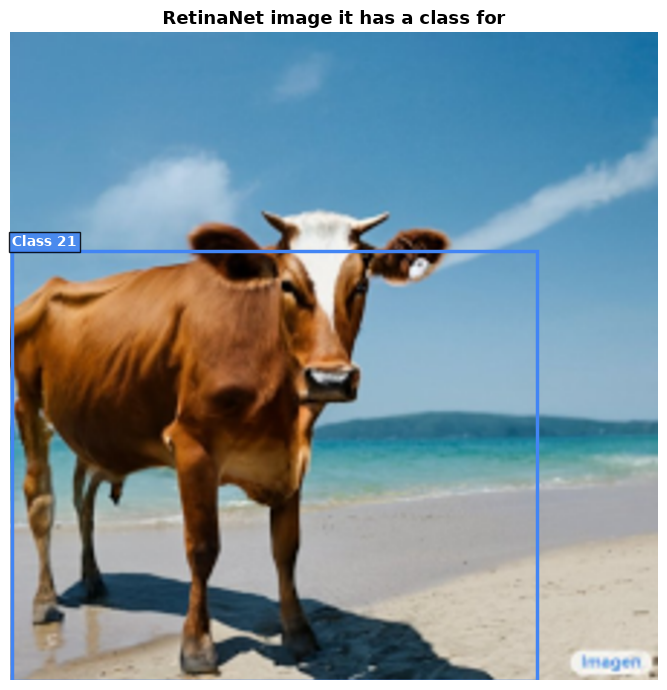

In [ ]:
# example zero-shot image (for known classes)

# Download an example image, load it, and get it in the correct format
image_url = "https://storage.googleapis.com/keras-cv/models/paligemma/cow_beach_1.png"
image_path = keras.utils.get_file(origin=image_url)
image = keras.utils.load_img(image_path).resize((IMAGE_SIZE, IMAGE_SIZE))
image_batch = np.expand_dims(keras.utils.img_to_array(image), axis=0)

# Make the prediction
coco_preds = baseline_detector.predict(image_batch)

# Plot it!
plot_bounding_boxes(
    image=image_batch[0],
    boxes=coco_preds["boxes"][0],
    labels=coco_preds["labels"][0],
    title="RetinaNet image it has a class for",
)


In [12]:
# Download an example dataset
dataset_path = kagglehub.dataset_download("pkdarabi/brain-tumor-image-dataset-semantic-segmentation")
print(f"{dataset_path}")

/usr/local/google/home/butterworthnat/.cache/kagglehub/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation/versions/1


Reading COCO-formatted (*whatever format your data is in*) data into Keras (*whatever framework you are using*) requires data wrangling to parse the data labels/annotation/folder/file structure and adapting them to what RetinaNet (*whatever deep learning model*) expects.

For example we must consider:

Bounding Box Coordinates: COCO uses [x_min, y_min, width, height] in raw pixels. Most Keras models and loss functions expect bounding boxes formatted as [y_min, x_min, y_max, x_max] (often normalized between 0.0 and 1.0).

Category ID Gaps: Standard COCO has 80 categories, but their IDs span from 1 to 90 (e.g., ID 12 is skipped). You must remap these to contiguous indices (0 to 79) so Keras doesn't run into index out-of-bounds errors.

There are various helper-functions and packages but we will just roll our own for completeness. 

In [13]:
# Wrangle the data!

# 1. Parse JSON and map annotations directly to images
anno_path = os.path.join(dataset_path, "train", "_annotations.coco.json")
with open(anno_path, "r") as f:
    coco_data = json.load(f)

# Create a dictionary of all the images
img_dict = {img["id"]: img for img in coco_data["images"]}

# Create a corresponding dictionary of all the annotations (labels, bounding boxes)
anno_dict = {}
for anno in coco_data["annotations"]:
    img_id = anno["image_id"]
    bbox = anno["bbox"]  # [xmin, ymin, width, height]
    category_id = anno["category_id"]
    if img_id not in anno_dict:
        anno_dict[img_id] = []
    anno_dict[img_id].append((bbox, category_id))

print(f"Total annotated images found in COCO file: {len(anno_dict)}")

# Subset the data (just to make the example go faster)
selected_img_ids = list(anno_dict.keys())[:SUBSET_SIZE]

images_list = []
boxes_list = []
labels_list = []

# Determine maximum detected object bounding boxes per image in subset for uniform data shapes
max_boxes = max(len(anno_dict[img_id]) for img_id in selected_img_ids)

for img_id in selected_img_ids:
    img_info = img_dict[img_id]
    file_name = img_info["file_name"]
    img_file_path = os.path.join(dataset_path, "train", file_name)
    
    # Load and resize image to standard input dimensions (640x640)
    pil_img = Image.open(img_file_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    orig_w, orig_h = img_info["width"], img_info["height"]
    scale_x = IMAGE_SIZE / orig_w
    scale_y = IMAGE_SIZE / orig_h

    # 2. Add all the objects (and their bounding boxes and class label) in each image
    img_boxes = []
    img_labels = []
    for bbox, _ in anno_dict[img_id]:
        xmin, ymin, w, h = bbox
        img_boxes.append([xmin * scale_x, ymin * scale_y, w * scale_x, h * scale_y])
        img_labels.append(0)  # Index 0 corresponding to DOMAIN_CLASSES[0]
        
    # Pad any "missing" object bounding boxes (-1 for background/padding label)
    while len(img_boxes) < max_boxes:
        img_boxes.append([0.0, 0.0, 0.0, 0.0])
        img_labels.append(-1)
        
    images_list.append(np.array(pil_img, dtype="float32"))
    boxes_list.append(img_boxes)
    labels_list.append(img_labels)

# Put the image, bounding boxes, and class labels into the correct format we need
train_images = np.array(images_list, dtype="float32")
train_boxes = np.array(boxes_list, dtype="float32")
train_classes = np.array(labels_list, dtype="int32")

train_targets = {
    "boxes": train_boxes,
    "labels": train_classes,
}

print(f"Images: {train_images.shape}")
print(f"Bounding Boxes: {train_boxes.shape}")
print(f"Class Labels: {train_classes.shape}\n")

Total annotated images found in COCO file: 1501
Images: (4, 640, 640, 3)
Bounding Boxes: (4, 1, 4)
Class Labels: (4, 1)



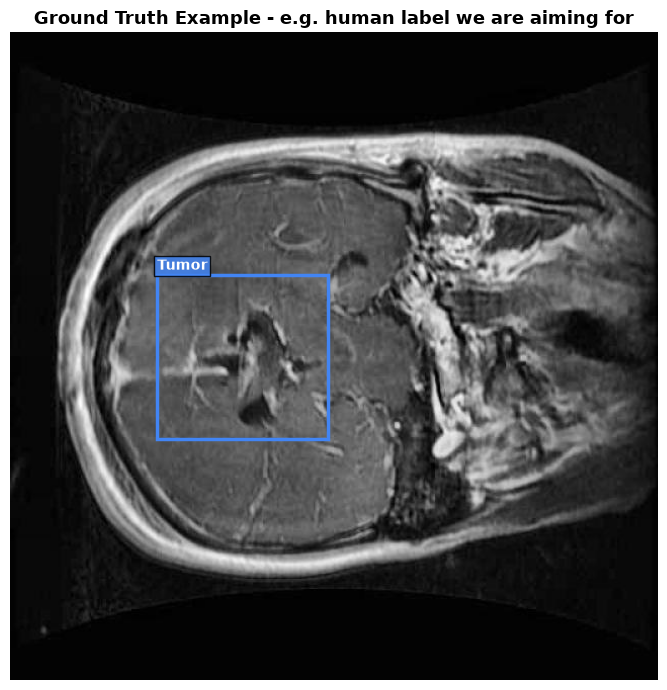

In [14]:
plot_bounding_boxes(
    image=train_images[0],
    boxes=train_boxes[0],
    labels=train_classes[0],
    class_names=DOMAIN_CLASSES,
    title="Ground Truth Example - e.g. human label we are aiming for"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
First predicted bbox: [-1. -1.  0.  0.]
First predicted label: -1


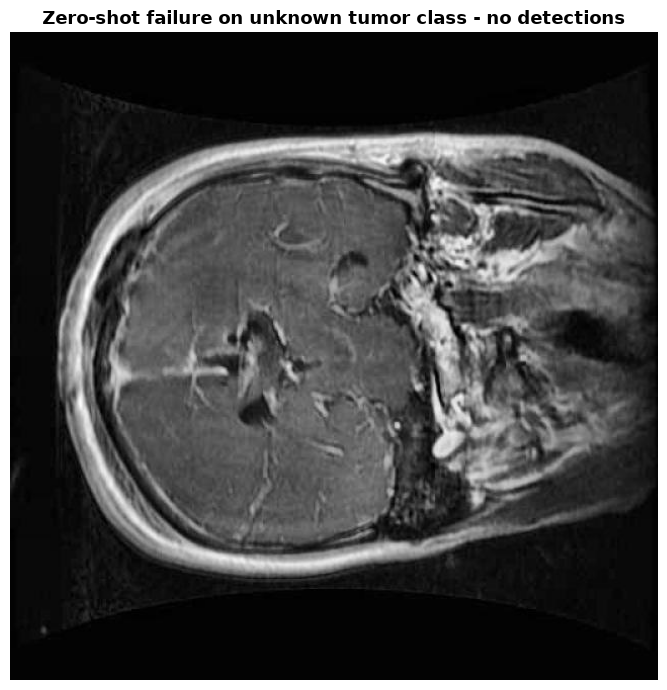

In [15]:
# Run the image through the model! Make a prediction.
baseline_preds = baseline_detector.predict(train_images[:1])

print(f"First predicted bbox: {baseline_preds["boxes"][0][0]}")
print(f"First predicted label: {baseline_preds["labels"][0][0]}")

plot_bounding_boxes(
    image=train_images[0],
    boxes=baseline_preds["boxes"][0],
    labels=baseline_preds["labels"][0],
    title="Zero-shot failure on unknown tumor class - no detections"
)

In [16]:
# Load the pre-trained Feature Pyramid Network (FPN) and Box Head.
custom_detector = keras_hub.models.RetinaNetObjectDetector.from_preset(
    "retinanet_resnet50_fpn_v2_coco",
    num_classes=NUM_CLASSES, 
    bounding_box_format=BBOX_FORMAT,
)

# Compile with options 
custom_detector.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    box_loss=keras.losses.Huber(delta=1.0, reduction="sum"),
    classification_loss=keras.losses.BinaryFocalCrossentropy(reduction="sum"),
)

In [17]:
history = custom_detector.fit(
    x=train_images,
    y=train_targets,
    epochs=1,
    batch_size=2,
)
print(f"  - Fine-tuning complete! Final Loss: {history.history['loss'][-1]:.4f}")

/usr/local/google/home/butterworthnat/miniforge3/envs/caigt/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2/2 ━━━━━━━━━━━━━━━━━━━━ 45s 14s/step - bbox_regression_loss: 2.0324 - cls_logits_loss: 15996.2412 - loss: 15998.2734  
  - Fine-tuning complete! Final Loss: 15998.2734


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
Prediction confidence: [0.9999999  0.9999999  0.9999969  0.9999944  0.9999753  0.9998988
 0.9998344  0.99980074 0.999684   0.9995535  0.9995233  0.99949837
 0.9992483  0.9989209  0.99883956 0.99795985 0.9976776  0.9973821
 0.997292   0.9971507  0.9968291  0.99632734 0.9959144  0.99550444
 0.995449   0.995376   0.9952798  0.99490875 0.9946765  0.99434423
 0.99424696 0.9939276  0.993707   0.9936655  0.993461   0.99341416
 0.9933831  0.9931125  0.99256283 0.99162805 0.9915359  0.9914601
 0.99121183 0.99083155 0.99067664 0.99053967 0.9904771  0.99019825
 0.98997074 0.9897008  0.9893728  0.9893243  0.9892972  0.9891857
 0.98917925 0.98883116 0.9888082  0.98867244 0.9877078  0.9876466
 0.98741186 0.98737574 0.98729104 0.987259   0.98722726 0.9871918
 0.98707217 0.9869376  0.98693335 0.98691726 0.98687404 0.98687345
 0.9868314  0.986749   0.9866555  0.9863978  0.98632425 0.98630095
 0.98603976 0.9859244  0.985693   0.9856323  0.98562974 0.9855479
 0.9852

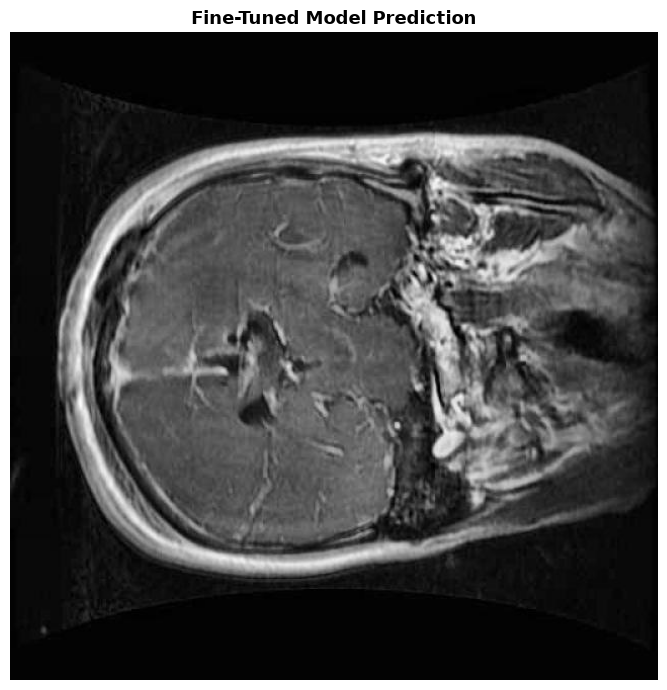

In [19]:
# Get the results
tuned_preds = custom_detector.predict(train_images[:1])

print(f"Prediction confidence: {tuned_preds["confidence"][0]}")

plot_bounding_boxes(
    image=train_images[0],
    boxes=tuned_preds["boxes"][0][0:2],
    labels=tuned_preds["labels"][0][0:2],
    class_names=DOMAIN_CLASSES,
    title="Fine-Tuned Model Prediction",
)

## Semantic Segmentation with DeepLabV3+

For our next task we will use [DeepLabV3+](https://www.kaggle.com/models/keras/deeplabv3plus) to perform semantic segmentation. DeepLabV3+ extends the original DeepLabV3 by introducing an explicit, lightweight Decoder module to refine segmentation results, especially along object boundaries. Two key features are Atrous (Dilated) Convolution and Atrous Spatial Pyramid Pooling (ASPP) to expand its field of view (receptive field) to capture broader context in parallel without increasing the number of parameters or losing spatial resolution through aggressive downsampling. It is pre-trained on [PASCAL VOC](https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/).

In [20]:
from PIL import ImageDraw

# Convert COCO Annotations into 2D Pixel Target Masks
SEG_CLASSES = ["Background", "Tumor"]
SEG_NUM_CLASSES = len(SEG_CLASSES)

train_masks_list = []

for img_id in selected_img_ids:
    # Create a blank 8-bit black mask (0 = Background) matching IMAGE_SIZE (640x640)
    mask_img = Image.new("L", (IMAGE_SIZE, IMAGE_SIZE), 0)
    draw = ImageDraw.Draw(mask_img)
    
    img_info = img_dict[img_id]
    orig_w, orig_h = img_info["width"], img_info["height"]
    scale_x = IMAGE_SIZE / orig_w
    scale_y = IMAGE_SIZE / orig_h
    
    # Rasterize bounding box regions as filled mask regions (1 = Tumor)
    for bbox, _ in anno_dict[img_id]:
        xmin, ymin, w, h = bbox
        x0, y0 = xmin * scale_x, ymin * scale_y
        x1, y1 = x0 + (w * scale_x), y0 + (h * scale_y)
        draw.rectangle([x0, y0, x1, y1], fill=1)
        
    train_masks_list.append(np.array(mask_img, dtype="int32"))

train_masks = np.array(train_masks_list, dtype="int32")

In [21]:
# Visualisation Helper Function for Semantic Segmentation
def plot_segmentation_comparison(image, ground_truth, prediction, title="Segmentation Result"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    img_disp = np.array(image, dtype="uint8")
    
    axes[0].imshow(img_disp)
    axes[0].set_title("Input MRI Scan", weight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(img_disp)
    axes[1].imshow(ground_truth, cmap="jet", alpha=0.45, vmin=0, vmax=1)
    axes[1].set_title("Ground Truth Mask", weight="bold")
    axes[1].axis("off")
    
    axes[2].imshow(img_disp)
    axes[2].imshow(prediction, cmap="jet", alpha=0.45, vmin=0, vmax=1)
    axes[2].set_title("DeepLabV3+ Predicted Mask", weight="bold")
    axes[2].axis("off")
    
    plt.suptitle(title, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

In [22]:
# Load DeepLabV3+ Segmenter
custom_segmenter = keras_hub.models.DeepLabV3ImageSegmenter.from_preset(
    "deeplab_v3_plus_resnet50_pascalvoc",
    num_classes=SEG_NUM_CLASSES,
)

100%|██████████| 1.71k/1.71k [00:00<00:00, 2.50MB/s]


100%|██████████| 4.32k/4.32k [00:00<00:00, 6.37MB/s]


100%|██████████| 299M/299M [00:21<00:00, 14.3MB/s] 


100%|██████████| 150M/150M [00:13<00:00, 11.6MB/s] 


In [23]:
# Align the preprocessor (trained on 512x512 images) to match our 640x640 images 
custom_segmenter.preprocessor.image_converter.image_size = (IMAGE_SIZE, IMAGE_SIZE)

# Compile using SparseCategoricalCrossentropy (for integer sparse masks)
custom_segmenter.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="pixel_accuracy")],
)

In [24]:
# 4. Fine-Tune DeepLabV3+ 
print("Starting DeepLabV3+ Fine-Tuning Loop...")

seg_history = custom_segmenter.fit(
    x=train_images,
    y=train_masks,
    epochs=1,
    batch_size=2,
)

print(f"Fine-Tuning Complete! Final Loss: {seg_history.history['loss'][-1]:.4f}")

Starting DeepLabV3+ Fine-Tuning Loop...
2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 8s/step - loss: 0.6051 - pixel_accuracy: 0.7072
Fine-Tuning Complete! Final Loss: 0.6051


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


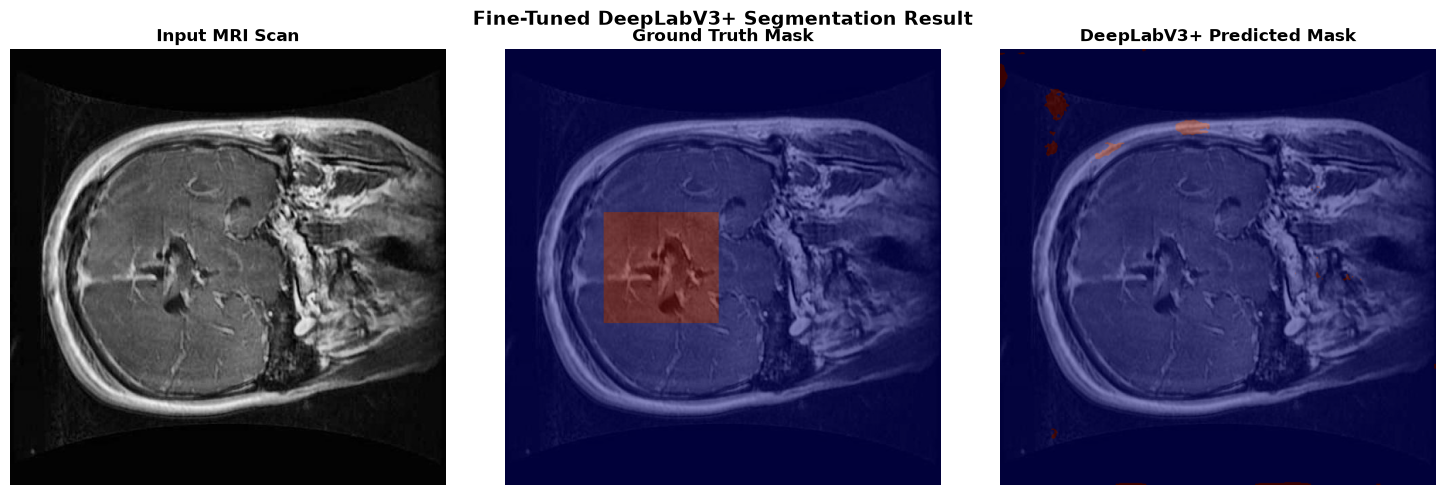

In [25]:
# Test the inference
pred_logits = custom_segmenter.predict(train_images[:1])

# Convert 3D class logits (H, W, num_classes) to 2D categorical class map (H, W)
pred_mask = np.argmax(pred_logits[0], axis=-1)

plot_segmentation_comparison(
    image=train_images[0],
    ground_truth=train_masks[0],
    prediction=pred_mask,
    title="Fine-Tuned DeepLabV3+ Segmentation Result"
)

## Multimodal AI

In [27]:
# kagglehub.login()

# Try paligemma or gemm4
gemma = keras_hub.models.PaliGemmaCausalLM.from_preset("pali_gemma_3b_224")
PROMPT = "detect tumor\n"
# Read more model syntax: https://ai.google.dev/gemma/docs/paligemma/inference-with-keras

# gemma = keras_hub.models.Gemma4CausalLM.from_preset("gemma4_instruct_2b")
# PROMPT = "Give me the bounding box coordinates for any tumors in this mri scan of a brain\n"

output_text = gemma.generate({
    "images": train_images[0],
    "prompts": PROMPT,
})
print(f"Gemma Output: {repr(output_text)}\n")

Gemma Output: 'detect tumor\n<loc0148><loc0070><loc0867><loc1023> tumor'



In [33]:
# Visualisation Helper Function
import re

def parse_gemma_boxes(output_text, img_width, img_height):
    """
    Parses bounding box coordinates from PaliGemma/Gemma model text outputs.
    Supports location tokens (<locYMIN><locXMIN><locYMAX><locXMAX>),
    JSON formats (e.g. {"box_2d": [ymin, xmin, ymax, xmax], "label": "..."}),
    and generic coordinate arrays.
    """
    if not isinstance(output_text, str):
        output_text = str(output_text)

    boxes = []
    labels = []

    # 1. Location token format (<locYMIN><locXMIN><locYMAX><locXMAX>)
    loc_pattern = r"<loc\s*(\d+)><loc\s*(\d+)><loc\s*(\d+)><loc\s*(\d+)>\s*(.*)"
    loc_matches = re.findall(loc_pattern, output_text)
    if loc_matches:
        print("match 1")
        for ymin_s, xmin_s, ymax_s, xmax_s, label in loc_matches:
            ymin_val, xmin_val = float(ymin_s), float(xmin_s)
            ymax_val, xmax_val = float(ymax_s), float(xmax_s)
            y1 = int(ymin_val / 1000.0 * img_height)
            x1 = int(xmin_val / 1000.0 * img_width)
            y2 = int(ymax_val / 1000.0 * img_height)
            x2 = int(xmax_val / 1000.0 * img_width)
            w = max(1, x2 - x1)
            h = max(1, y2 - y1)
            boxes.append([x1, y1, w, h])
            labels.append(label.strip() if label.strip() else "tumor")
        return boxes, labels

    # 2. JSON / box_2d format
    box2d_pattern = r'"box_2d"\s*:\s*\[\s*([\d\.]+)\s*,\s*([\d\.]+)\s*,\s*([\d\.]+)\s*,\s*([\d\.]+)\s*\]'
    box2d_matches = list(re.finditer(box2d_pattern, output_text))
    if box2d_matches:
        print("match 2")
        for match in box2d_matches:
            ymin_val = float(match.group(1))
            xmin_val = float(match.group(2))
            ymax_val = float(match.group(3))
            xmax_val = float(match.group(4))

            label = "tumor"
            start_idx = max(0, match.start() - 100)
            end_idx = min(len(output_text), match.end() + 100)
            context_str = output_text[start_idx:end_idx]
            label_match = re.search(r'"(?:label|name|class)"\s*:\s*"([^"]+)"', context_str)
            if label_match:
                label = label_match.group(1)

            max_coord = max(abs(ymin_val), abs(xmin_val), abs(ymax_val), abs(xmax_val))
            if max_coord <= 1.0:
                y1 = int(ymin_val * img_height)
                x1 = int(xmin_val * img_width)
                y2 = int(ymax_val * img_height)
                x2 = int(xmax_val * img_width)
            elif max_coord <= 1000.0:
                y1 = int(ymin_val / 1000.0 * img_height)
                x1 = int(xmin_val / 1000.0 * img_width)
                y2 = int(ymax_val / 1000.0 * img_height)
                x2 = int(xmax_val / 1000.0 * img_width)
            else:
                y1 = int(ymin_val)
                x1 = int(xmin_val)
                y2 = int(ymax_val)
                x2 = int(xmax_val)

            w = max(1, x2 - x1)
            h = max(1, y2 - y1)
            boxes.append([x1, y1, w, h])
            labels.append(label)
        return boxes, labels

    # 3. Fallback to generic 4-number list match
    list_pattern = r'\[\s*([\d\.]+)\s*,\s*([\d\.]+)\s*,\s*([\d\.]+)\s*,\s*([\d\.]+)\s*\]'
    list_matches = list(re.finditer(list_pattern, output_text))
    print("match 3")
    for match in list_matches:
        ymin_val = float(match.group(1))
        xmin_val = float(match.group(2))
        ymax_val = float(match.group(3))
        xmax_val = float(match.group(4))

        max_coord = max(abs(ymin_val), abs(xmin_val), abs(ymax_val), abs(xmax_val))
        if max_coord <= 1.0:
            y1 = int(ymin_val * img_height)
            x1 = int(xmin_val * img_width)
            y2 = int(ymax_val * img_height)
            x2 = int(xmax_val * img_width)
        elif max_coord <= 1000.0:
            y1 = int(ymin_val / 1000.0 * img_height)
            x1 = int(xmin_val / 1000.0 * img_width)
            y2 = int(ymax_val / 1000.0 * img_height)
            x2 = int(xmax_val / 1000.0 * img_width)
        else:
            y1 = int(ymin_val)
            x1 = int(xmin_val)
            y2 = int(ymax_val)
            x2 = int(xmax_val)

        w = max(1, x2 - x1)
        h = max(1, y2 - y1)
        boxes.append([x1, y1, w, h])
        labels.append("tumor")

    return boxes, labels

def plot_predictions(image, boxes, labels, title="Gemma Prediction", output_path="04_cv4_gemma_prediction.png"):
    """
    Renders an image with overlaid bounding boxes parsed from Gemma output.
    """
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(image)
    
    colors = ["#EA4335", "#4285F4", "#FBBC04", "#34A853"]
    if boxes:
        for idx, (box, label) in enumerate(zip(boxes, labels)):
            xmin, ymin, w, h = box
            color = colors[idx % len(colors)]
            rect = patches.Rectangle((xmin, ymin), w, h, linewidth=2.5, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(
                xmin, max(15.0, ymin - 5.0), label,
                color="white", fontsize=10, weight="bold",
                bbox=dict(boxstyle="square,pad=0.2", facecolor=color, alpha=0.85)
            )
            
    ax.set_title(title, fontsize=13, weight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


match 1
Parsed 1 bounding box(es).


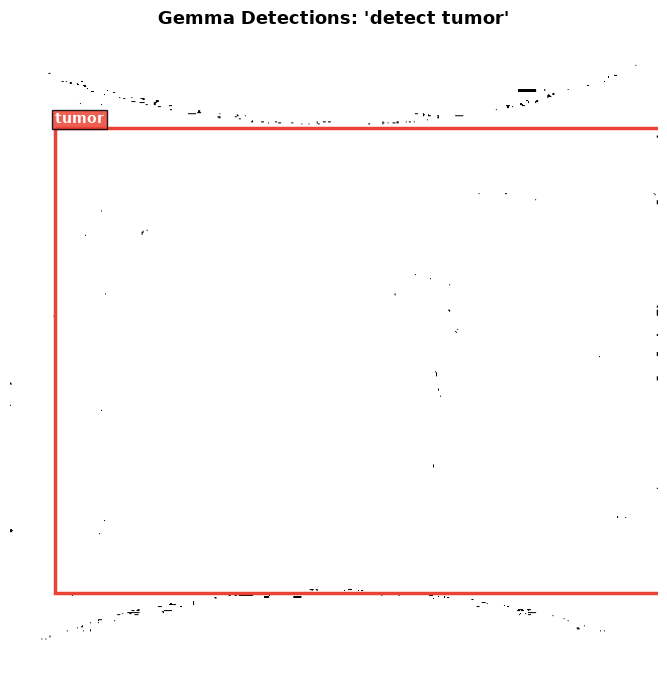

In [34]:
boxes, labels = parse_gemma_boxes(output_text, train_images[0].shape[1], train_images[0].shape[0])
print(f"Parsed {len(boxes)} bounding box(es).")
plot_predictions(train_images[0], boxes, labels, title=f"Gemma Detections: '{PROMPT.strip()}'")